# imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import matplotlib.pyplot as plt
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from feature_engine.datetime import DatetimeFeatures
from feature_engine.creation import CyclicalFeatures
from feature_engine.timeseries.forecasting import ExpandingWindowFeatures,LagFeatures
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sktime.transformations.series.fourier import FourierFeatures
from feature_engine.timeseries.forecasting import WindowFeatures
import holidays
from sklearn.ensemble import RandomForestRegressor
from mlforecast import MLForecast
from neuralforecast import NeuralForecast
import optuna
import itertools
import numpy as np
from xgboost import XGBRegressor
import re


c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
def plot_predictions(model_name, df_validation_y, all_preds_unscaled):
    plt.figure(figsize=(14, 7))

    # Plot actual values
    plt.plot(df_validation_y.index, df_validation_y.values, label='Actual Values', color='blue', linewidth=2)

    # Plot predicted values
    plt.plot(all_preds_unscaled.index, all_preds_unscaled.values, label=f'Predicted Values ({model_name})', color='red', linestyle='-', linewidth=2)

    # Add labels and title
    plt.xlabel('Time')
    plt.ylabel('Load')
    plt.title(f'Actual vs Predicted Values ({model_name})')

    # Add legend
    plt.legend()

    # Rotate x-ticks for better readability
    plt.xticks(rotation=45)

    # Show the plot
    plt.tight_layout()
    plt.show()

def CreateWorkHourFeature(input_data):
    """
    Receives as input a DataFrame or Series and outputs a DataFrame with the working hours during the day.
    When the day of the week is larger than 4, it is considered a weekend (1), otherwise, it's a workday (0).
    During workdays and between 8:00 and 17:00, it is considered a working hour.

    Parameters:
    input_data (DataFrame or Series): Input data with a DatetimeIndex.

    Returns:
    DataFrame: DataFrame with the added "WorkingHour_flag" column.
    """
    if isinstance(input_data, pd.Series):
        input_df = pd.DataFrame(input_data)
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data
    else:
        raise ValueError("Input must be a DataFrame or Series.")

    assert isinstance(input_df.index, pd.DatetimeIndex), "Index must be a datetime index."

    input_df["dayOfWeek"] = input_df.index.dayofweek
    input_df.loc[input_df["dayOfWeek"] > 4, "weekendFlag"] = 1
    input_df.loc[input_df["dayOfWeek"] < 5, "weekendFlag"] = 0
    input_df["hour"] = input_df.index.hour
    input_df["WorkingHour_flag"] = 0
    input_df.loc[((input_df["hour"] > 8) & (input_df["hour"] < 17) & (input_df["weekendFlag"] == 0)), "WorkingHour_flag"] = 1
    input_df.drop(["hour", "dayOfWeek", "weekendFlag"], axis=1, inplace=True)

    return input_df


def ListCreatorFlagger(df, substrings=['flag', 'cos', 'sin','day_of_week', 'day_of_month', 'weekend', 'days_in_month', 'hour', 'minute']):
    """
    A function that separates the columns containing specified substrings from those that don't.
    df is the dataframe in question and the substring is a list.
    """
    flag_columns = [col for col in df.columns if any(substring in col for substring in substrings)]

    if not flag_columns:
        print("No columns with the specified substrings found.")
        return None, None

    non_flag_columns = [col for col in df.columns if col not in flag_columns]

    return non_flag_columns, flag_columns


def HolidayFeatureCreator(input_data, countries):
    """
    Receives a DataFrame or Series and creates a column 'Holidays_flag'
    which is 1 if the date is a holiday in ANY of the given countries.
    """

    if isinstance(input_data, pd.Series):
        input_df = pd.DataFrame(input_data)
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data.copy()
    else:
        raise ValueError("Input must be a DataFrame or Series.")

    if not isinstance(input_df.index, pd.DatetimeIndex):
        raise ValueError("Index must be a DatetimeIndex.")

    years = input_df.index.year.unique().tolist()

    country_map = {
        "Germany": holidays.DE,
        "Ireland": holidays.IE,
        "Portugal": holidays.PT,
        "Denmark": holidays.DK,
    }

    holiday_dates = set()

    for country in countries:
        if country not in country_map:
            raise ValueError(f"{country} not supported")
        h = country_map[country](years=years)
        holiday_dates.update(h.keys())

    # convert index dates to pandas Index so .isin works
    index_dates = pd.Index(input_df.index.date)

    input_df["Holidays_flag"] = index_dates.isin(holiday_dates).astype(int)

    return input_df




def TimeRelatedFeatureConstructor(df):
  """
  Works only in a dataframe as input: run the other functions first.
  Extracts time-related features
  """
  TimeFeaturesToExtract=["day_of_week","weekend","hour",] #consider to add more
  dtfs=DatetimeFeatures(variables="index", features_to_extract=TimeFeaturesToExtract, drop_original=False)
  df=dtfs.fit_transform(df)

  CyclicalFeaturesToExtract=["day_of_week","hour",]
  cyclical_dtfs=CyclicalFeatures(variables=CyclicalFeaturesToExtract,drop_original=False)
  df=cyclical_dtfs.fit_transform(df)
  return df


def FourierFeatureConstructor(df, granularity, fourier_terms_list):
    # Extract numerical part of granularity
    number_part = ''.join(filter(str.isdigit, granularity))
    number_int = int(number_part) if number_part else 1  # Fallback to 1 to avoid division by zero

    # Calculate minutes per hour, ensuring no division by zero
    minutes4hour = 60 / number_int if number_int != 0 else 60

    # Define seasonal periods (sp_list) for Fourier transformation
    sp_list = [
        max(minutes4hour, 4),                 # Hourly - for 15min, this should be 4
        max(24 * minutes4hour, 96),           # Daily - for 15min, this should be 96
        max(24 * 7 * minutes4hour, 672),      # Weekly - for 15min, this should be 672
        max(24 * 30 * minutes4hour, 2880)     # Monthly - for 15min, this should be 2880
    ]

    # Fourier transformer setup
    Fourier_Transformer = FourierFeatures(
        sp_list=sp_list,
        fourier_terms_list=fourier_terms_list,
        freq=granularity,
        keep_original_columns=True
    )

    # Apply Fourier transformation
    Fourier_Transformer.fit(df)
    df = Fourier_Transformer.transform(df)
    return df



def WindowFeaturesConstructor(df, granularity, ListWithNoFlags):
    """
    This is a function that makes a list of 4 window features starting from double the granularity and following by doubling the previous value
    """
    number_part = ''.join(filter(str.isdigit, granularity))
    number_int = int(number_part)
    double_granularity = 2 * number_int
    time_intervals = [double_granularity]

    # Calculate subsequent values
    for i in range(3):
        time_intervals.append(time_intervals[-1] * 2)

    windowlist = [interval // number_int for interval in time_intervals]  # Corrected division
    functionsList = ["mean", "std"]
    WindownFeatureTransformer = WindowFeatures(variables=ListWithNoFlags,
                                               functions=functionsList,
                                               window=windowlist,
                                               freq=granularity,
                                               drop_original=False)

    df = WindownFeatureTransformer.fit_transform(df)
    return df

def ExpandingWindowFeatureConstructor(df,ListWithNoFlags):
  functionsList=["mean","std"]
  frequency = pd.infer_freq(df.index) #infer the frequency from the dataframe
  ExpandingWindownFeatureTransformer=ExpandingWindowFeatures(variables=ListWithNoFlags,
                                                           functions=functionsList,
                                                           freq=frequency, #I put the freq to shift it down! but now it is performed automatically!
                                                           drop_original=False)
  df=ExpandingWindownFeatureTransformer.fit_transform(df)
  return df

def WeightedLinearFeatureMaker(df,ListWithNoFlags,granularity):
  """
  This is a function that takes the original DF and modifies the continious value columns
  Inputs: Dataframe, List of columns that are continous values, daily window to slide, weights of the values
  """
  number_part = ''.join(filter(str.isdigit, granularity))
  Minutedensity=int(number_part)
  Window=int((60/Minutedensity)*24) #288 means a daily window
  weights=np.arange(1,Window+1)

  # if i had hourly data then i would have had np.arange(1,24*7) for a weekly window

  def weighted_mean (x,weights):
    return (weights*x).sum()/weights.sum()

  def weighted_std(x,weights):
    mean_w= weighted_mean(x, weights)
    var_w= (weights* (x-mean_w)**2).sum()/weights.sum()
    return np.sqrt(var_w)

  # LETS make the weighted mean column
  for i in ListWithNoFlags:
    result=(
        df[i]
        .rolling(window=Window) #here we pick a window size. Needs to be the same as the len(weights)
        .apply(weighted_mean, args=(weights,))
        .shift(1)#shift by 1 to avoid data leakage
        .to_frame()#convert series to df
        )

    result.columns=[str(i)+"_weighted_"+str(Window)+"_mean"]
    df=df.join(result)

  for i in ListWithNoFlags:
    result=(
        df[i]
        .rolling(window=Window) #here we pick a window size. Needs to be the same as the len(weights)
        .apply(weighted_std, args=(weights,))
        .shift(1)#shift by 1 to avoid data leakage
        .to_frame()#convert series to df
        )

    result.columns=[str(i)+"_weighted_"+str(Window)+"_std"]
    df=df.join(result)
  return df

def ExpWeightMeanMaker(df,ListWithNoFlags,granularity):
  """
  This is a function that makes exp weighted average with a sliding window approach
  """
  number_part = ''.join(filter(str.isdigit, granularity))
  Minutedensity=int(number_part)
  Window=int((60/Minutedensity)*24) #288 means a daily window

  def exp_weights(alpha,window_size):
    """
    a function to calculate the weights for every single component of our sliding windown
    """
    weights=np.ones(window_size) #initializing weights
    for ix in range(window_size):
      weights[ix]=(1-alpha)**(window_size-1-ix)
    return weights

  def exp_weighted_mean(x):
    """
    a functions that calculates the exp weigted mean
    """

    weights=exp_weights(alpha=0.05, window_size=len(x)) # HERE WE SET THE ALPHA
    return (weights*x).sum()/weights.sum()

  for i in ListWithNoFlags:
    result=(
        df[i]
        .rolling(window=int(Window))
        .agg([exp_weighted_mean])
        .shift(1)
    )


    result.columns=[str(i)+"_Exp_weighted_"+str(Window)+"_SL.win"]
    df=df.join(result)
  return df



def FeatureLagger(df, ListOfFeatures, granularity, PredictionHorizon):
    number_part = ''.join(filter(str.isdigit, granularity))
    Minutedensity = int(number_part)

    time_intervals = [f"{i * Minutedensity}min" for i in range(1, PredictionHorizon + 1)]

    lag_transformer = LagFeatures(
        variables=ListOfFeatures,
        freq=time_intervals,
        drop_original=False
    )

    df = lag_transformer.fit_transform(df)
    return df



def ErrorCalculator(name, y_true, y_pred):
    errors = {"Pipelines": name,
              "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
              "MAE": mean_absolute_error(y_true, y_pred),
              "MSE": mean_squared_error(y_true, y_pred),

             }
    return errors


def separate_future_past_features(df_columns):
    """
    Separates future and past features from a list of dataframe columns.

    Args:
        df_columns (list): A list of column names from the dataframe.

    Returns:
        dict: A dictionary with keys 'future_features' and 'past_features', containing the respective lists of column names.
    """
    future_keywords = ['sin', 'cos', 'weekend', 'hour', 'holiday', 'minute', 'day','+']

    future_features = []
    past_features = []

    for col in df_columns:
        # Check if the column contains "+" in its name to classify as a past feature
        if any(keyword in col.lower() for keyword in future_keywords):
            future_features.append(col)
        # Columns that don't meet the above conditions are considered past features by default
        else:
            past_features.append(col)

    return future_features, past_features


def plot_errors (ErrorSeries):
  """
  This is a function that plots the features that are not
  """
  import matplotlib as mpl
  import matplotlib.pyplot as plt
  import matplotlib.path as mpath
  import numpy as np

  import matplotlib.pyplot as plt
  import numpy as np

  x = np.arange(len(ErrorSeries.index))
  y = ErrorSeries.values
  labels = ErrorSeries.index

  plt.figure(1,figsize=(13,5))
  plt.style.use("seaborn-v0_8-whitegrid")
  plt.plot(x, y)

  plt.xticks(x, labels, rotation =40)
  plt.ylabel('RMSE [€/MWh]', wrap=True)
  plt.xlabel('Features', wrap=True)


  plt.margins(0.05)

  plt.subplots_adjust(bottom = 0.05)
  plt.show()


def select_features_minimum_plus_others(series):
    """
    Takes a pandas Series and selects the features that:
    - Include all features up to the minimum error.
    - After the minimum error, only include features that reduce the error compared to the previous one.
    - Ensures no duplicate features are added.

    Parameters:
    - series: A pandas Series where index are feature names and values are errors.

    Returns:
    - A list of selected feature names without duplicates.
    """
    # Find the index of the minimum value
    min_idx = series.idxmin()

    # Select all features up to and including the minimum
    selected_features = list(dict.fromkeys(series[:min_idx].index.tolist() + [min_idx]))

    # After the minimum, keep only the features that decrease the error
    after_min_series = series[min_idx:]

    # Loop through the series after the minimum value and add features that decrease the error
    for i in range(1, len(after_min_series)):
        if after_min_series[i] < after_min_series[i - 1]:
            feature = after_min_series.index[i]
            if feature not in selected_features:
                selected_features.append(feature)

    return selected_features

def keep_indices_till_min(series):
    """
    Keeps all index values from the series up to and including the minimum value using a for loop,
    while ensuring no duplicates are added.

    Parameters:
    - series: A pandas Series where the index are feature names and the values are errors.

    Returns:
    - A list of unique index values (features) up to and including the minimum error value.
    """
    # Initialize an empty list to store the selected indices
    selected_features = []

    # Find the minimum value in the series
    min_value = series.min()

    # Loop over the series
    for idx, value in series.items():
        # Add the current index to the selected features only if it's not already present
        if idx not in selected_features:
            selected_features.append(idx)

        # If the current value is the minimum, stop the loop
        if value == min_value:
            break

    return selected_features

def laggedColumnCreator(df,columnName,lagStart, lagInterval, lagEnd):
  for i in range(lagStart, lagEnd+1, lagInterval):
     newColumnName = columnName + "-" + str(i) + "step" #you gotta put it in string
     df[newColumnName] = df[columnName].shift(i)
  return df


def make_splits(
    test_start_str: str,
    freq: str = "15min",      # your timestep
    val_days: int = 14,
    train_steps: int = 7000,
    test_days: int = 14,       # length of test period
):
    step = pd.to_timedelta(freq)

    # TEST
    test_start = pd.Timestamp(test_start_str)
    # If you slice df.loc[start:end] (inclusive), use -step to get exactly `test_days` worth of data
    test_end = test_start + pd.Timedelta(days=test_days)

    # VALIDATION (ends one step before test_start)
    validation_end = test_start - step
    # `val_days` long, inclusive: end - start = val_days days - step
    validation_start = validation_end - pd.Timedelta(days=val_days) + step

    # TRAIN (ends one step before validation_start)
    train_end = validation_start - step
    # exactly `train_steps` steps long: end - start = (train_steps - 1) * step
    train_start = validation_start - train_steps * step

    return {
        "train_start": train_start,
        "train_end": train_end,
        "validation_start": validation_start,
        "validation_end": validation_end,
        "test_start": test_start,
        "test_end": test_end,
    }


def FeatureSelection(regressor, DF_features, DF_target, ordered_features_list, test_size=672, tolerance=400):
    """
    This function receives a regressor model, the features that the model was trained with,
    and the target that it had to forecast. Starting from the most important feature,
    we find the error of the TimeSeries Cross-Validation with a fixed test size.
    By adding features, we find the new error of the forecast.

    Parameters:
    - regressor: The regression model to use for training and prediction.
    - DF_features: DataFrame containing the features.
    - DF_target: Series containing the target variable.
    - ordered_features_list: List of features ordered by importance (e.g., from SHAP analysis).
    - test_size: Number of steps to use in the test set (default is 672).
    - tolerance: Number of features to add before stopping if no improvement in error (default is 20).

    Returns:
    - ErrorSeries: A pandas Series with the errors for each step of feature addition.
    """

    feature_list = []  # Empty list of features
    error_list = []  # Empty list to store errors for each set of features
    total_samples = len(DF_features)  # Total number of samples in the dataset
    n_splits = 5  # Number of splits (fixed)
    no_improvement_count = 0  # Count features added without improvement
    min_error = float('inf')  # Start with a large error to track the minimum error

    for i in ordered_features_list:
        # Start the loop with the best feature and append the next ones
        feature_list.append(i)

        X = DF_features[feature_list].to_numpy()
        y = DF_target.to_numpy()

        #print(f"Performing feature selection with features: {feature_list}")

        # Custom logic to create splits with a fixed test size of 672
        splits = []
        start_train_size = total_samples - (n_splits * test_size)  # Calculate where to start training

        for split in range(n_splits):
            train_end = start_train_size + split * test_size
            test_start = train_end
            test_end = test_start + test_size

            if test_end <= total_samples:  # Ensure the test set is within the bounds
                splits.append((list(range(0, train_end)), list(range(test_start, test_end))))

        TimeSeriesCVerror = []  # MSE errors for each fold

        # Time series cross-validation with fixed test size
        for train_index, test_index in splits:
            #print(f"TRAIN: {train_index}, TEST: {test_index}")
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Train the regressor and predict
            regressor.fit(X_train, y_train)
            predicted_val = regressor.predict(X_test)

            # Calculate the error for this fold
            Error = np.sqrt(mean_squared_error(y_test, predicted_val))
            TimeSeriesCVerror.append(Error)
            #print(f"This is the error for one TS iteration: {Error}")

        # Calculate the average error across all splits
        TS_CV_error = sum(TimeSeriesCVerror) / len(TimeSeriesCVerror)
        #print(f"Cumulative error of the last steps: {TS_CV_error}")
        error_list.append(TS_CV_error)  # Store the error for this set of features

        # Check if the error improved
        if TS_CV_error < min_error:
            min_error = TS_CV_error  # Update the minimum error
            no_improvement_count = 0  # Reset the no-improvement count
        else:
            no_improvement_count += 1  # Increment if there's no improvement

        # Break the loop if no improvement is observed after 20 features
        if no_improvement_count >= tolerance:
            print(f"No improvement after {tolerance} features. Stopping early.")
            break

    # Create a pandas Series to store the error associated with each feature
    ErrorSeries = pd.Series(error_list, index=feature_list)

    # Plot the errors using a custom plot function
    plot_errors(ErrorSeries)

    return ErrorSeries



def build_feature_matrix(
    df_target,
    df_features,
    countries,
    granularity="15min",
    prediction_horizon=96,
    fourier_terms_list=[2, 2, 2, 2]
):
    """
    Combines target + exogenous features and creates engineered features.
    Returns:
        full_df: dataframe containing target and engineered features
        target_col: name of target column
    """

    target_name = df_target.name if df_target.name is not None else "target"

    full_df = pd.DataFrame(index=df_target.index)
    full_df[target_name] = df_target.astype(float)
    full_df = full_df.join(df_features.astype(float), how="left")

    # Calendar / deterministic features
    full_df = CreateWorkHourFeature(full_df)
    full_df = HolidayFeatureCreator(full_df, countries=countries)
    full_df = TimeRelatedFeatureConstructor(full_df)
    full_df = FourierFeatureConstructor(
        full_df,
        granularity=granularity,
        fourier_terms_list=fourier_terms_list
    )

    # Separate columns for rolling/expanding transforms
    non_flag_cols, flag_cols = ListCreatorFlagger(full_df)

    # Remove target from the list if present
    non_flag_cols = [c for c in non_flag_cols if c != target_name]

    # Rolling/expanding on continuous predictors
    if len(non_flag_cols) > 0:
        full_df = WindowFeaturesConstructor(full_df, granularity, non_flag_cols)
        full_df = ExpandingWindowFeatureConstructor(full_df, non_flag_cols)
        full_df = WeightedLinearFeatureMaker(full_df, non_flag_cols, granularity)
        full_df = ExpWeightMeanMaker(full_df, non_flag_cols, granularity)

    lag_features = [target_name] + list(df_features.columns)

    # Lags of target
    full_df = FeatureLagger(
        full_df,
        ListOfFeatures=lag_features,
        granularity=granularity,
        PredictionHorizon=prediction_horizon
    )

    return full_df, target_name


def make_train_val_nextday_split(full_df, target_col, freq="15min", val_days=3, pred_len=96):
    step = pd.to_timedelta(freq)
    val_steps = int(pd.Timedelta(days=val_days) / step)

    full_df = full_df.dropna().copy()

    min_required = val_steps + pred_len
    if len(full_df) <= min_required:
        raise ValueError(
            f"Not enough usable history after dropna. "
            f"Need more than {min_required} rows, got {len(full_df)}."
        )

    train_df = full_df.iloc[:-val_steps].copy()
    val_df = full_df.iloc[-val_steps:].copy()

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_val = val_df.drop(columns=[target_col])
    y_val = val_df[target_col]

    last_ts = full_df.index[-1]
    future_index = pd.date_range(
        start=last_ts + step,
        periods=pred_len,
        freq=freq
    )

    return X_train, y_train, X_val, y_val, future_index, full_df
    
def FeatureSelectionOnValidation(regressor, X_train, y_train, X_val, y_val, ordered_features_list, tolerance=20):
    feature_list = []
    error_list = []

    no_improvement_count = 0
    min_error = np.inf

    for feat in ordered_features_list:
        feature_list.append(feat)

        regressor.fit(X_train[feature_list], y_train)
        pred_val = regressor.predict(X_val[feature_list])
        mse = mean_squared_error(y_val, pred_val)
        error_list.append(mse)

        if mse < min_error:
            min_error = mse
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        if no_improvement_count >= tolerance:
            print(f"No improvement after {tolerance} added features. Stopping early.")
            break

    error_series = pd.Series(error_list, index=feature_list)
    return error_series


def tune_xgboost_on_validation(X_train, y_train, X_val, y_val):
    param_grid = {
        "n_estimators": [200, 400],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "reg_lambda": [1, 5],
    }

    keys = list(param_grid.keys())
    best_model = None
    best_params = None
    best_mse = np.inf

    for values in itertools.product(*(param_grid[k] for k in keys)):
        params = dict(zip(keys, values))

        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            tree_method="hist",
            **params
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse = mean_squared_error(y_val, y_pred)

        if mse < best_mse:
            best_mse = mse
            best_model = model
            best_params = params

    return best_model, best_params, best_mse

def build_future_feature_matrix(
    history_target,
    history_features,
    future_features,
    countries,
    freq="15min",
    pred_len=96,
    fourier_terms_list=[2, 2, 2, 2]
):
    """
    Builds a feature matrix for the next day.
    Assumes future_features is available for the future timestamps if you want weather.
    """

    future_index = future_features.index
    target_name = history_target.name if history_target.name is not None else "target"

    # combine history + empty future target
    df_hist = pd.DataFrame(index=history_target.index)
    df_hist[target_name] = history_target.astype(float)
    df_hist = df_hist.join(history_features, how="left")

    df_future = pd.DataFrame(index=future_index)
    df_future[target_name] = np.nan
    df_future = df_future.join(future_features, how="left")

    full_df = pd.concat([df_hist, df_future], axis=0)

    # deterministic features
    full_df = CreateWorkHourFeature(full_df)
    full_df = HolidayFeatureCreator(full_df, countries=countries)
    full_df = TimeRelatedFeatureConstructor(full_df)
    full_df = FourierFeatureConstructor(
        full_df,
        granularity=freq,
        fourier_terms_list=fourier_terms_list
    )

    # rolling features on exogenous continuous cols
    non_flag_cols, flag_cols = ListCreatorFlagger(full_df)
    non_flag_cols = [c for c in non_flag_cols if c != target_name]

    if len(non_flag_cols) > 0:
        full_df = WindowFeaturesConstructor(full_df, freq, non_flag_cols)
        full_df = ExpandingWindowFeatureConstructor(full_df, non_flag_cols)
        full_df = WeightedLinearFeatureMaker(full_df, non_flag_cols, freq)
        full_df = ExpWeightMeanMaker(full_df, non_flag_cols, freq)

    # lag target using history only
    full_df = FeatureLagger(
        full_df,
        ListOfFeatures=[target_name],
        granularity=freq,
        PredictionHorizon=pred_len
    )

    return full_df.loc[future_index].copy()

# start

In [3]:
DAYS_JSON = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\dataset_days.json"
DATA_DIR  = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean"
OUT_DIR   = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\Outputs"

#countries = ["Germany", "Ireland", "Portugal"]
countries = ["Germany"]

#days = ["day1", "day2", "day3", "day4", "day5"]
days = ["day1"]
fourier_terms_list=[2,2,2,2]
granularity="15min"
prediction_horizon="1440min"
features = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "direct_radiation",
]

PRED_LEN = 96
CONTEXT_TAIL = 10000
VAL_DAYS=3

with open(DAYS_JSON, "r") as f:
    dataset_days = json.load(f)

In [4]:
for country in countries:
    print("\nProcessing country:", country)

    data_path = os.path.join(DATA_DIR, f"dataset_{country.capitalize()}.csv")
    df = pd.read_csv(data_path, index_col="timestamp", parse_dates=True).sort_index()

    households = [c for c in df.columns if c not in features]

    for day in days:
        print("   Day:", day)
        cutoff = pd.to_datetime(dataset_days[country][day])

        # Prefer real timestamps from data for alignment
        future_index = df.loc[df.index >= cutoff].index[:PRED_LEN]
        if len(future_index) < PRED_LEN:
            inferred = pd.infer_freq(df.index)
            if inferred is None:
                deltas = df.index.to_series().diff().dropna()
                step = deltas.mode().iloc[0]
                future_index = pd.date_range(start=cutoff, periods=PRED_LEN, freq=step)
            else:
                future_index = pd.date_range(start=cutoff, periods=PRED_LEN, freq=inferred)

        predictions_df_all_households = pd.DataFrame(index=future_index)
        predictions_df_all_households.index.name = "timestamp"

        rmse_households = []

        for household in households:
            # history slice (univariate)
            df_target = df.loc[df.index < cutoff, household].astype(float).dropna()

            if len(df_target) < 10:
                predictions_df_all_households[household] = np.nan
                continue

            df_target = df_target.tail(CONTEXT_TAIL)
            df_features_hist = df[features].reindex(df_target.index).copy()


Processing country: Germany
   Day: day1


In [5]:
df_target

timestamp
2019-09-15 20:00:00     418.532999
2019-09-15 20:15:00     418.260667
2019-09-15 20:30:00     460.002889
2019-09-15 20:45:00     513.824777
2019-09-15 21:00:00     506.319223
                          ...     
2019-12-28 22:45:00    1482.557569
2019-12-28 23:00:00    3530.273341
2019-12-28 23:15:00    2219.273998
2019-12-28 23:30:00    2562.174353
2019-12-28 23:45:00    3119.577761
Name: home_28, Length: 10000, dtype: float64

In [ ]:
    # 1. build engineered matrix
    full_df, target_col = build_feature_matrix(
        df_target=df_target,
        df_features=df_features_hist,
        countries=[country],
        granularity="15min",
        prediction_horizon=PRED_LEN,
        fourier_terms_list=[2, 2, 2, 2]
    )
    print("raw target length:", len(df_target))
    print("feature df length before dropna:", len(full_df))
    print("feature df length after dropna:", len(full_df.dropna()))

    # 2. split into train / validation
    try:
        X_train, y_train, X_val, y_val, nextday_index, full_df_clean = make_train_val_nextday_split(
            full_df,
            target_col,
            freq="15min",
            val_days=VAL_DAYS,
            pred_len=PRED_LEN
        )
    except ValueError as e:
        print(f"{household} skipped: {e}")
        predictions_df_all_households[household] = np.nan


    # --------------------------------------------------
    # Train Random Forest
    # --------------------------------------------------
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # --------------------------------------------------
    # Get feature importances
    # --------------------------------------------------
    feature_importances = pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)



    # If you want a Python list ordered by importance
    importance_list = feature_importances.index.tolist()


    # --------------------------------------------------
    # Sort feature importances
    # --------------------------------------------------
    feature_importances = feature_importances.sort_values(ascending=False)

    # --------------------------------------------------
    # Compute cumulative importance
    # --------------------------------------------------
    cumulative_importance = feature_importances.cumsum()

    # --------------------------------------------------
    # Keep features explaining 90% importance
    # --------------------------------------------------
    selected_features = cumulative_importance[cumulative_importance <= 0.90].index.tolist()

    # include the first feature that crosses 90%
    if len(selected_features) < len(feature_importances):
        selected_features.append(feature_importances.index[len(selected_features)])
    print("number of selected features:", len(selected_features))
    X_train = X_train[selected_features]
    X_val = X_val[selected_features]
            

raw target length: 10000
feature df length before dropna: 10000
feature df length after dropna: 9904


In [18]:
len(selected_features)

245

In [21]:
# ==========================================================
# 3. Convert selected features into:
#    - MLForecast lags (from target lag columns)
#    - exogenous columns (everything else)
# ==========================================================
def extract_mlf_lags_and_exog(selected_features, target_col, freq_min=15):
    lag_pattern = re.compile(rf"^{re.escape(target_col)}_lag_(\d+)min$")
    mlf_lags = []
    exog_features = []

    for col in selected_features:
        m = lag_pattern.match(col)
        if m:
            lag_minutes = int(m.group(1))
            lag_steps = lag_minutes // freq_min
            if lag_steps >= 1:
                mlf_lags.append(lag_steps)
        else:
            exog_features.append(col)

    mlf_lags = sorted(list(set(mlf_lags)))
    return mlf_lags, exog_features


mlf_lags, exog_features = extract_mlf_lags_and_exog(
    selected_features=selected_features,
    target_col=target_col,
    freq_min=15
)

print("MLForecast lags:", mlf_lags)
print("Number of exogenous selected features:", len(exog_features))
print("Exogenous selected features:", exog_features)

MLForecast lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96]
Number of exogenous selected features: 149
Exogenous selected features: ['temperature_2m', 'temperature_2m_window_16_mean', 'relative_humidity_2m_expanding_mean', 'temperature_2m_window_8_mean', 'temperature_2m_expanding_std', 'temperature_2m_Exp_weighted_96_SL.win', 'temperature_2m_lag_15min', 'temperature_2m_window_2_mean', 'temperature_2m_lag_30min', 'relative_humidity_2m_expanding_std', 'temperature_2m_window_4_mean', 'temperature_2m_lag_120min', 'precipitation_expanding_std', 'precipitation_expanding_mean', 'temperature_2m_lag_60min', 'temperature_2m_lag_105min', 'wind_speed_10m_expanding_mean',


Processing country: Germany
  Day: day1
    Household: home_1
    usable rows: 9904


c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually

    Number of generated features: 197
    Total features: 197
    Selected features (90% cum. importance): 128
    Top 20 features:
lag1                              0.310127
lag3                              0.045105
lag96                             0.030098
lag2                              0.021328
sin_2880.0_2                      0.016795
lag4                              0.012759
rolling_mean_lag4_window_size4    0.011832
hour_cos                          0.008019
lag95                             0.007800
rolling_std_lag4_window_size4     0.007553
lag6                              0.006003
lag10                             0.005830
sin_4.0_1                         0.005707
hour_sin                          0.005173
lag84                             0.005147
lag7                              0.005132
lag85                             0.005116
lag26                             0.005047
lag88                             0.005007
sin_4.0_2                         0.004823
dtype: f

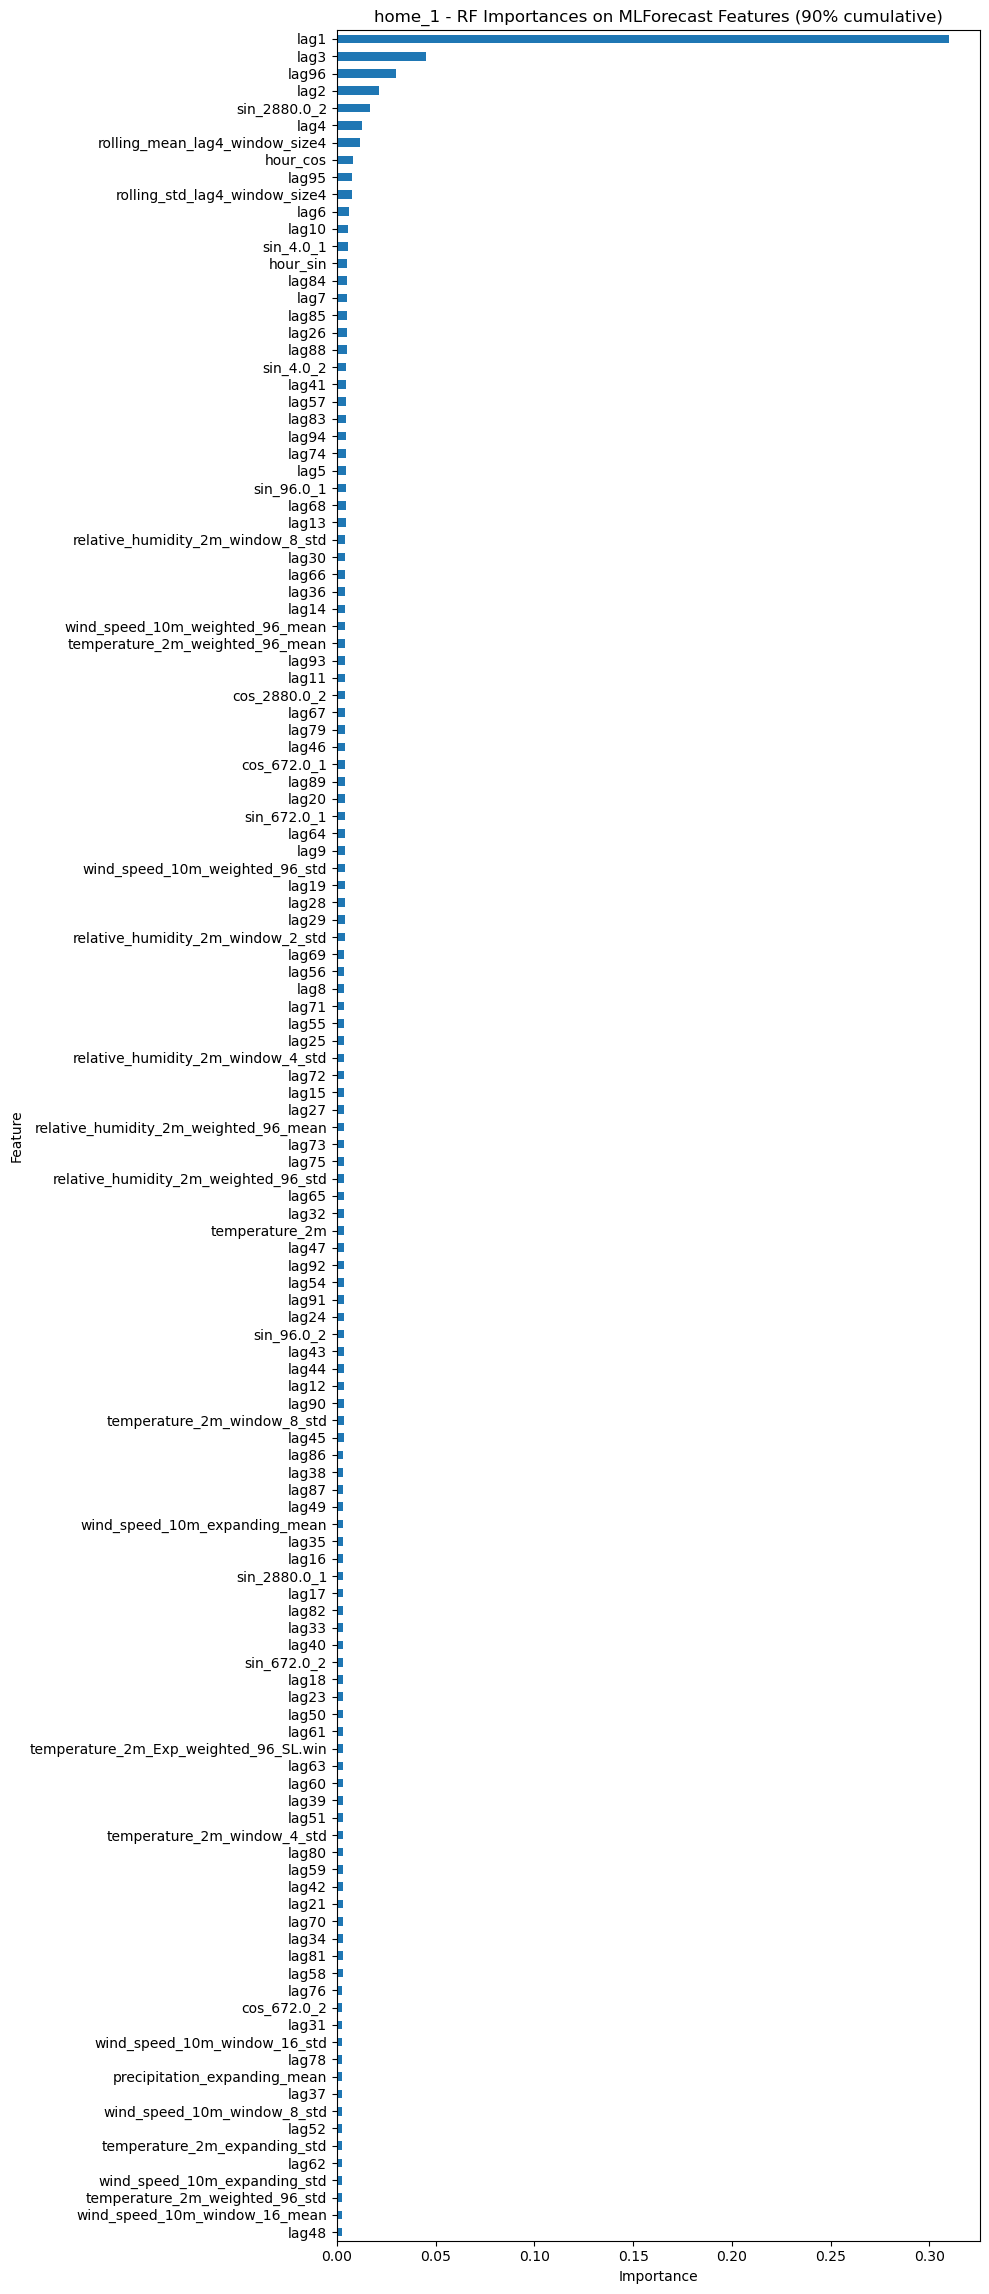

    Validation RMSE: 893.2417
    Household: home_2
    usable rows: 9904


c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually

    Number of generated features: 197
    Total features: 197
    Selected features (90% cum. importance): 127
    Top 20 features:
lag3                              0.216695
lag1                              0.081005
temperature_2m                    0.055154
lag2                              0.038794
temperature_2m_window_2_mean      0.030118
lag14                             0.027143
lag15                             0.025836
lag5                              0.016895
sin_2880.0_2                      0.012402
lag16                             0.008664
lag4                              0.008033
temperature_2m_window_4_mean      0.007619
lag28                             0.006751
rolling_mean_lag4_window_size4    0.005971
cos_2880.0_2                      0.005936
lag6                              0.005696
wind_speed_10m_expanding_mean     0.005586
lag96                             0.005170
rolling_std_lag4_window_size4     0.005081
lag8                              0.004859
dtype: f

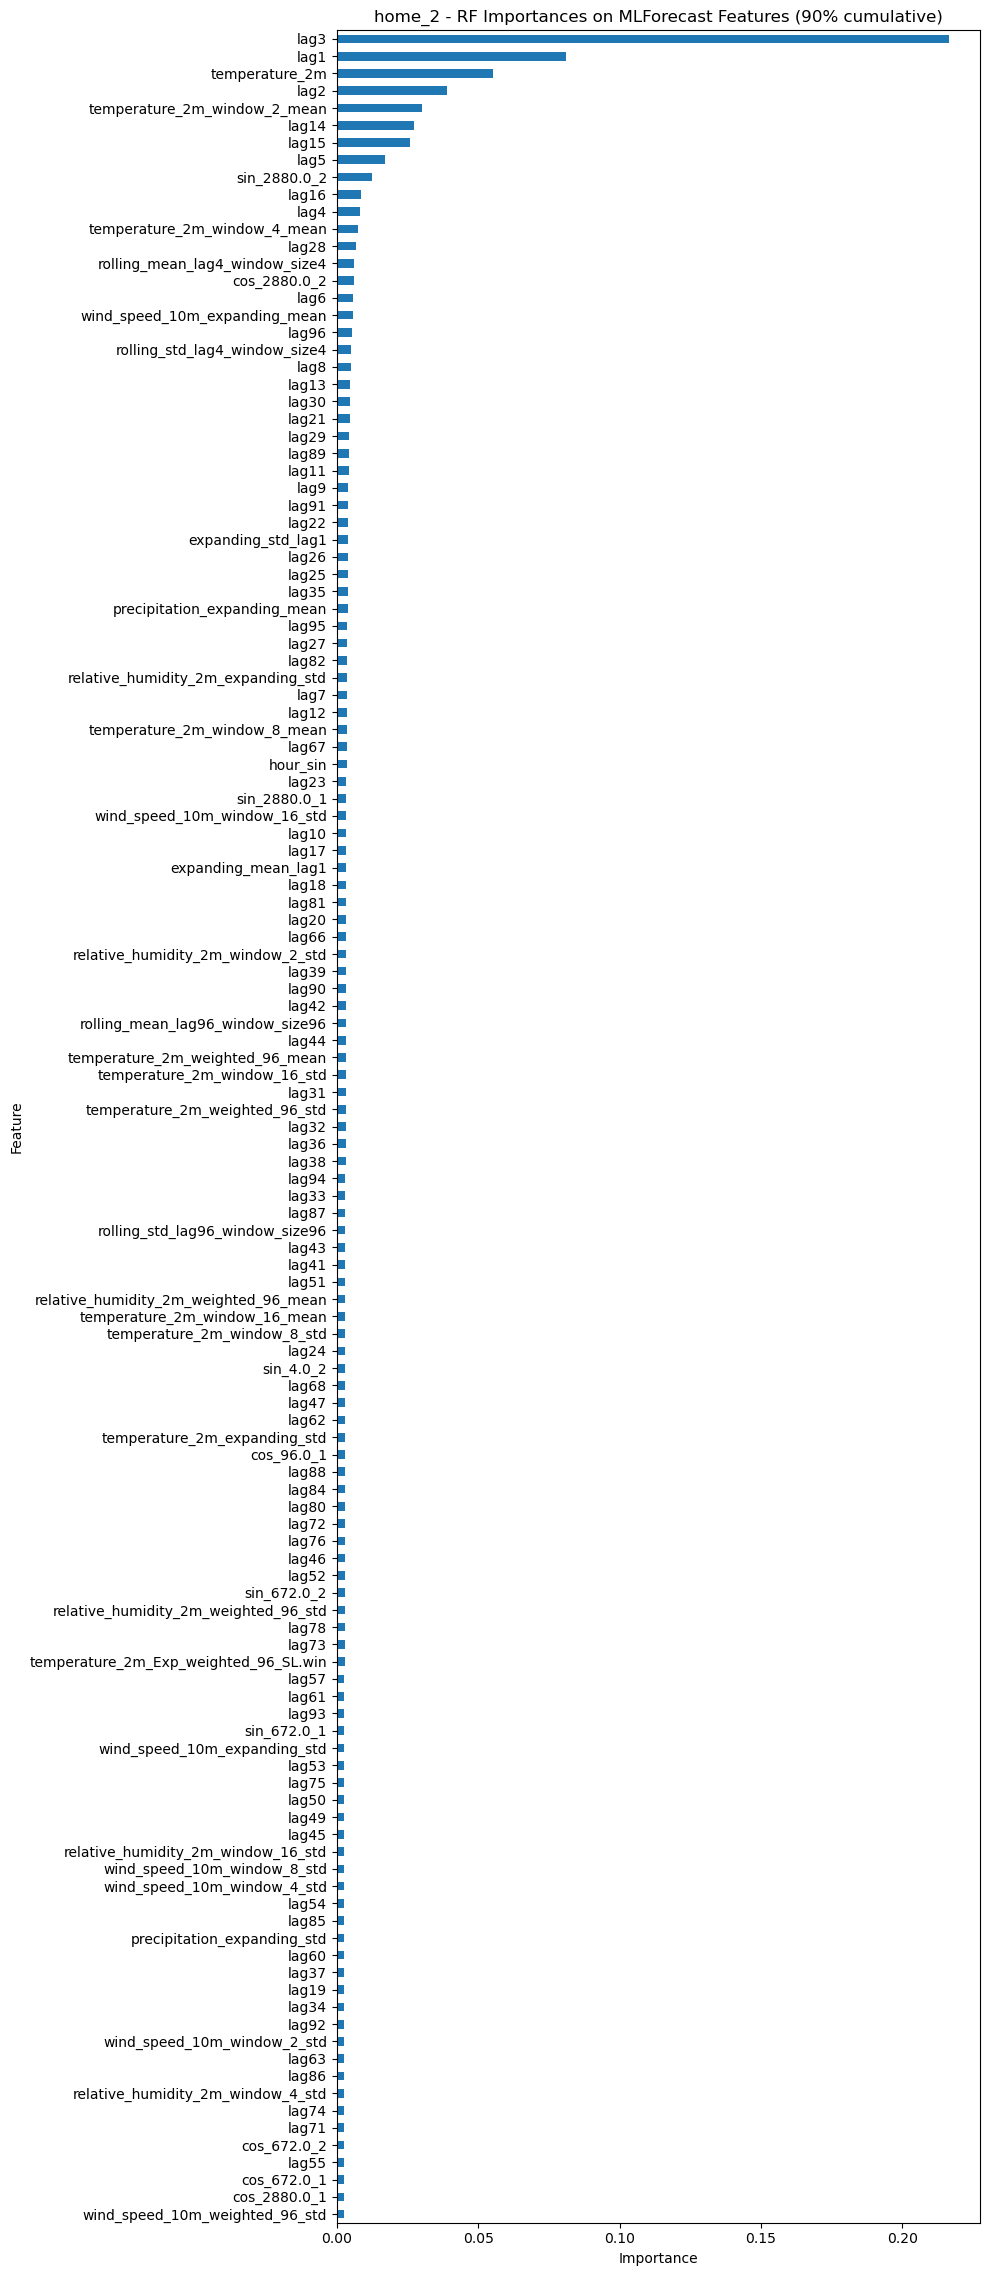

    Validation RMSE: 808.7142
    Household: home_3
    usable rows: 9904


c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually

    Number of generated features: 197


KeyboardInterrupt: 

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd, ExpandingMean, ExpandingStd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# ============================================================
# CONFIG
# ============================================================
DAYS_JSON = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\dataset_days.json"
DATA_DIR  = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean"
OUT_DIR   = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\Outputs"

countries = ["Germany"]
days = ["day1"]

features = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "direct_radiation",
]

PRED_LEN = 96
VAL_DAYS = 3
CONTEXT_TAIL = 10000


# ============================================================
# MAIN
# ============================================================
with open(DAYS_JSON, "r") as f:
    dataset_days = json.load(f)

for country in countries:
    print(f"\nProcessing country: {country}")

    data_path = os.path.join(DATA_DIR, f"dataset_{country.capitalize()}.csv")
    df = pd.read_csv(data_path, index_col="timestamp", parse_dates=True).sort_index()

    households = [c for c in df.columns if c not in features]

    for day in days:
        print(f"  Day: {day}")
        cutoff = pd.to_datetime(dataset_days[country][day])

        predictions_df_all_households = pd.DataFrame()
        rmse_households = []

        for household in households:
            print(f"    Household: {household}")

            # ------------------------------------------------
            # 1. History only up to cutoff
            # ------------------------------------------------
            df_target = df.loc[df.index < cutoff, household].astype(float).dropna()
            if len(df_target) < 500:
                print(f"    {household} skipped: too little history")
                continue

            df_target = df_target.tail(CONTEXT_TAIL)
            df_features_hist = df.loc[df_target.index, features].copy()

            # ------------------------------------------------
            # 2. Build MLForecast input without manual target lags
            # ------------------------------------------------
            long_df = make_long_target_exog(df_target, df_features_hist, household)
            long_df = add_calendar_and_fourier_exog(
                long_df,
                countries=[country],
                granularity="15min",
                fourier_terms_list=[2, 2, 2, 2]
            )

            long_df = long_df.dropna().copy()

            print("    usable rows:", len(long_df))

            try:
                train_df, val_df = split_train_val_long(
                    long_df,
                    val_days=VAL_DAYS,
                    freq="15min"
                )
            except ValueError as e:
                print(f"    {household} skipped: {e}")
                continue

            # ------------------------------------------------
            # 3. Let MLForecast create target lags automatically
            # ------------------------------------------------
            fcst = MLForecast(
                models={
                        models={
                            "rf": RandomForestRegressor(
                                n_estimators=300,
                                max_depth=None,
                                random_state=42,
                                n_jobs=-1
                            )
                },
                freq="15min",
                lags=list(range(1, PRED_LEN + 1)),  # 1..96 target lags
                lag_transforms={
                    1: [ExpandingMean(), ExpandingStd()],
                    4: [RollingMean(window_size=4), RollingStd(window_size=4)],
                    96: [RollingMean(window_size=96), RollingStd(window_size=96)],
                },
                date_features=[]  # you already create calendar/fourier manually
            )

            # ------------------------------------------------
            # 4. Fit once
            # ------------------------------------------------
            fcst.fit(
                train_df,
                id_col="unique_id",
                time_col="ds",
                target_col="y",
                static_features=[]
            )

            # ------------------------------------------------
            # 5. Inspect the generated training matrix
            #    This is the key trick: no manual lag-name parsing
            # ------------------------------------------------
            train_features = fcst.preprocess(
                train_df,
                id_col="unique_id",
                time_col="ds",
                target_col="y",
                static_features=[]
            )

            # remove id/time/target to get pure X matrix
            feature_cols = [c for c in train_features.columns if c not in ["unique_id", "ds", "y"]]
            X_train_rf = train_features[feature_cols].copy()
            y_train_rf = train_features["y"].copy()

            print("    Number of generated features:", len(feature_cols))

            # ------------------------------------------------
            # 6. Random Forest feature importance on full generated matrix
            # ------------------------------------------------
            rf = RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
            rf.fit(X_train_rf, y_train_rf)

            feature_importances = pd.Series(
                rf.feature_importances_,
                index=X_train_rf.columns
            ).sort_values(ascending=False)

            cumulative_importance = feature_importances.cumsum()
            selected_features = cumulative_importance[cumulative_importance <= 0.90].index.tolist()
            if len(selected_features) < len(feature_importances):
                selected_features.append(feature_importances.index[len(selected_features)])

            print("    Total features:", len(feature_importances))
            print("    Selected features (90% cum. importance):", len(selected_features))
            print("    Top 20 features:")
            print(feature_importances.head(20))

            # ------------------------------------------------
            # 7. Plot selected features only
            # ------------------------------------------------
            selected_importances = feature_importances.loc[selected_features].sort_values()

            plt.figure(figsize=(10, max(6, len(selected_importances) * 0.18)))
            selected_importances.plot(kind="barh")
            plt.title(f"{household} - RF Importances on MLForecast Features (90% cumulative)")
            plt.xlabel("Importance")
            plt.ylabel("Feature")
            plt.tight_layout()
            plt.show()

            # ------------------------------------------------
            # 8. Validation forecast with MLForecast
            # ------------------------------------------------
            X_df_val = get_future_exog_for_val(val_df)

            preds_val = fcst.predict(
                h=len(val_df),
                X_df=X_df_val
            )

            pred_col = [c for c in preds_val.columns if c not in ["unique_id", "ds"]][0]
            y_val_pred = preds_val.set_index("ds")[pred_col].reindex(val_df["ds"])
            y_val_true = val_df.set_index("ds")["y"]

            rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
            rmse_households.append((household, rmse))

            print(f"    Validation RMSE: {rmse:.4f}")

# old code 


Processing country: Germany

  Day: day1

    Household: home_1
    usable rows: 9904
    Number of generated MLForecast features: 197


c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually

    Total generated features: 197
    Selected features: 154
    Top 20 selected/importances:
lag1                                  0.081455
lag2                                  0.027239
lag3                                  0.022528
rolling_mean_lag4_window_size4        0.021188
lag96                                 0.018708
lag4                                  0.017224
rolling_std_lag4_window_size4         0.017005
sin_2880.0_2                          0.015937
hour_sin                              0.012189
hour_cos                              0.010687
lag95                                 0.009583
lag5                                  0.008858
cos_2880.0_2                          0.007717
lag7                                  0.006683
lag88                                 0.006663
lag92                                 0.006652
lag6                                  0.006611
temperature_2m_weighted_96_mean       0.006373
lag85                                 0.006205
relative_humi

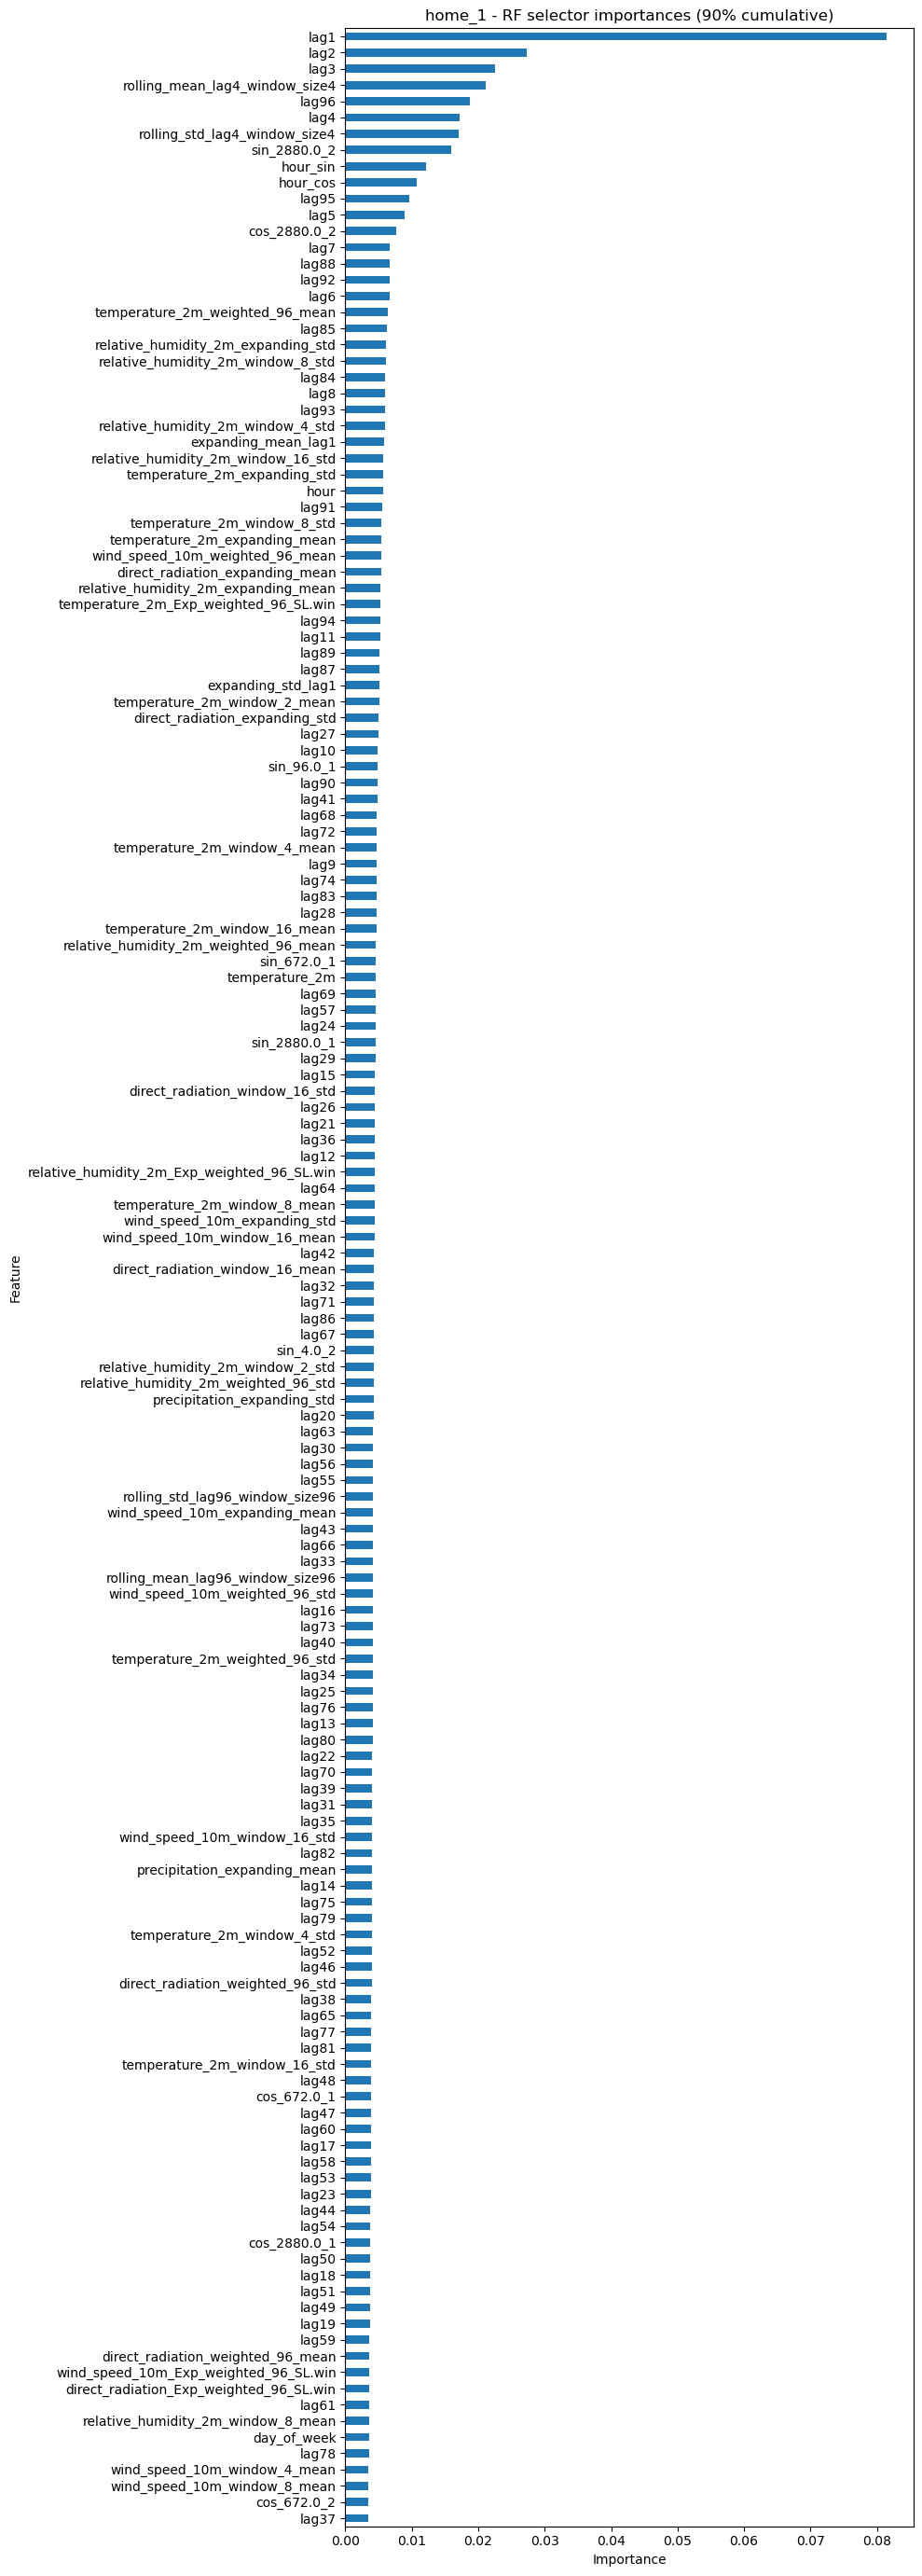

[I 2026-03-10 18:18:13,007] A new study created in memory with name: no-name-11731dbe-fe49-4a9d-981a-32a544a7c4f9
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\s

    Best validation RMSE: 851.1594839128315
    Best RF #2 params: {'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 0.5, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}
    Final validation RMSE: 851.1595

    Household: home_2
    usable rows: 9904
    Number of generated MLForecast features: 197


c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually

    Total generated features: 197
    Selected features: 149
    Top 20 selected/importances:
lag3                                     0.076208
lag1                                     0.032168
lag14                                    0.020713
lag15                                    0.019157
temperature_2m                           0.017261
temperature_2m_window_4_mean             0.017068
lag6                                     0.016097
temperature_2m_window_2_mean             0.014575
lag2                                     0.014133
direct_radiation_expanding_mean          0.012720
relative_humidity_2m_expanding_mean      0.012300
temperature_2m_Exp_weighted_96_SL.win    0.012197
relative_humidity_2m_expanding_std       0.011913
expanding_mean_lag1                      0.011504
temperature_2m_window_8_mean             0.011427
lag4                                     0.011406
temperature_2m_weighted_96_mean          0.010585
direct_radiation_expanding_std           0.009360
lag96 

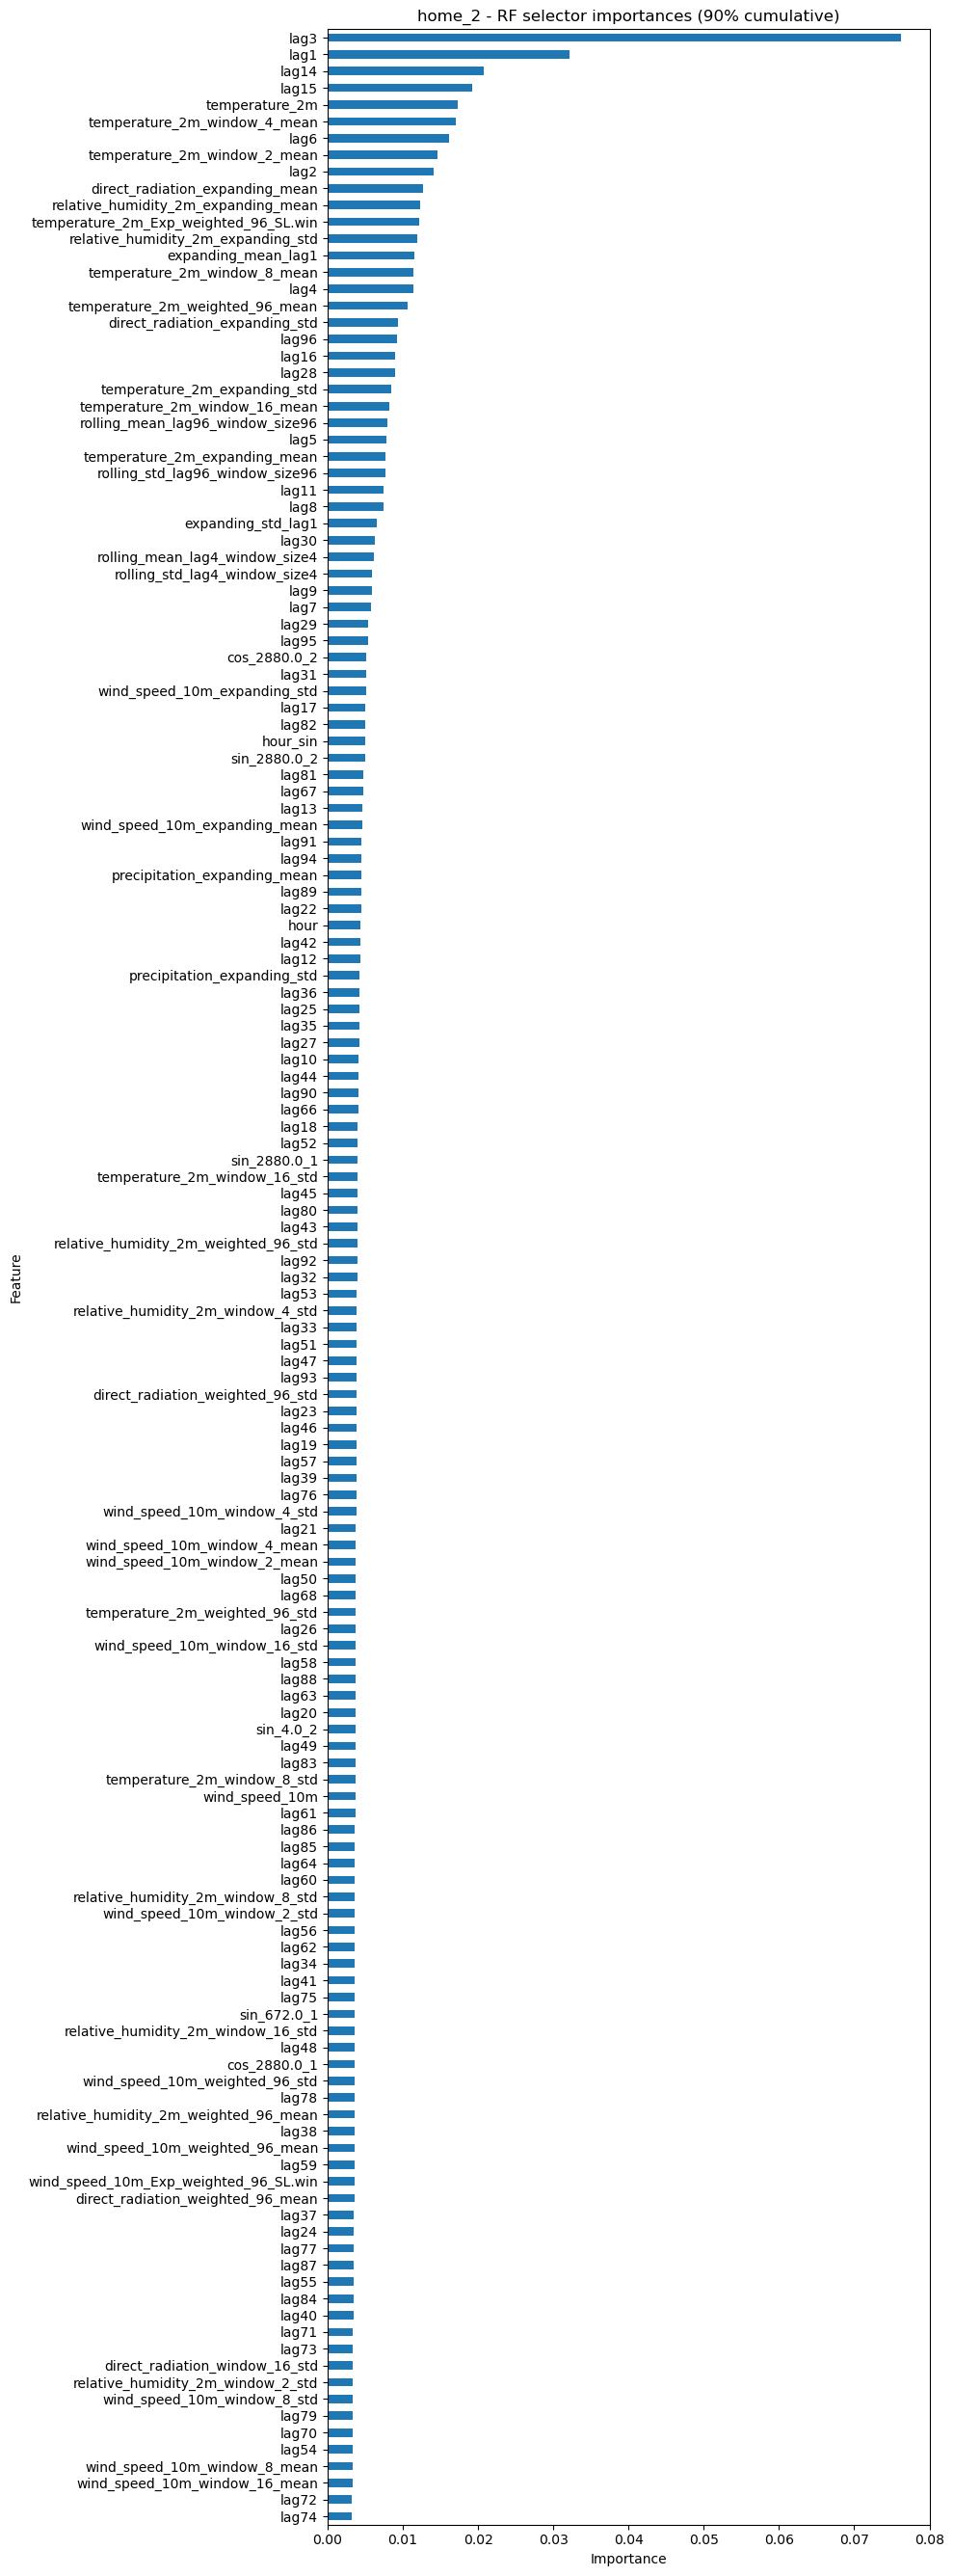

[I 2026-03-10 18:20:54,182] A new study created in memory with name: no-name-1a48c228-0abf-4a6f-880c-771f44f8e132
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\site-packages\utilsforecast\processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
c:\Users\CR58XM\AppData\Local\anaconda3\envs\nixtla_forecast\Lib\s

    Best validation RMSE: 794.6642162729107
    Best RF #2 params: {'n_estimators': 500, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}
    Final validation RMSE: 794.6642

Saved validation predictions to: C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\Outputs\validation_predictions_selected_rf_Germany_day1.csv
Saved validation truth to: C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\Outputs\validation_truth_selected_rf_Germany_day1.csv

Saved RMSE summary to: C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\Outputs\validation_rmse_selected_rf.csv
Saved best params summary to: C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\Outputs\best_params_selected_rf.csv


In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd, ExpandingMean, ExpandingStd


# ============================================================
# CONFIG
# ============================================================
DAYS_JSON = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\dataset_days.json"
DATA_DIR  = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean"
OUT_DIR   = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\Outputs"
SELECTED_FEATURES_DIR = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\Outputs\Selected_features"

countries = ["Germany"]
days = ["day1"]

features = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "direct_radiation",
]

PRED_LEN = 96
VAL_DAYS = 3
CONTEXT_TAIL = 10000
FEATURE_IMPORTANCE_THRESHOLD = 0.90
N_TRIALS = 3

# Fixed RF selector parameters
RF_SELECTOR_PARAMS = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "bootstrap": True,
    "random_state": 42,
    "n_jobs": -1,
}

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(SELECTED_FEATURES_DIR, exist_ok=True)


# ============================================================
# HELPER FUNCTIONS
# ============================================================
def make_long_target_exog(df_target, df_features, household):
    out = pd.DataFrame({
        "unique_id": household,
        "ds": df_target.index,
        "y": df_target.values,
    })
    out = out.merge(
        df_features.reset_index().rename(columns={df_features.index.name or "index": "ds"}),
        on="ds",
        how="left"
    )
    return out


def add_calendar_and_fourier_exog(df_long, countries, granularity="15min", fourier_terms_list=[2, 2, 2, 2]):
    """
    Adds only deterministic / exogenous features.
    No manual target lags here.
    Assumes the custom feature engineering functions are already in memory.
    """
    tmp = df_long.set_index("ds").copy()

    # deterministic / calendar / fourier
    tmp = CreateWorkHourFeature(tmp)
    tmp = HolidayFeatureCreator(tmp, countries=countries)
    tmp = TimeRelatedFeatureConstructor(tmp)
    tmp = FourierFeatureConstructor(
        tmp,
        granularity=granularity,
        fourier_terms_list=fourier_terms_list
    )

    # rolling / expanding / weighted features only on weather columns
    exog_cols = [c for c in features if c in tmp.columns]
    if len(exog_cols) > 0:
        tmp = WindowFeaturesConstructor(tmp, granularity, exog_cols)
        tmp = ExpandingWindowFeatureConstructor(tmp, exog_cols)
        tmp = WeightedLinearFeatureMaker(tmp, exog_cols, granularity)
        tmp = ExpWeightMeanMaker(tmp, exog_cols, granularity)

    tmp = tmp.reset_index()
    return tmp


def split_train_val_long(df_long, val_days=3, freq="15min"):
    step = pd.to_timedelta(freq)
    val_steps = int(pd.Timedelta(days=val_days) / step)

    df_long = df_long.sort_values("ds").reset_index(drop=True)

    if len(df_long) <= val_steps:
        raise ValueError(f"Not enough rows. Need > {val_steps}, got {len(df_long)}")

    train_df = df_long.iloc[:-val_steps].copy()
    val_df = df_long.iloc[-val_steps:].copy()

    return train_df, val_df


def get_future_exog_for_val(val_df):
    return val_df.drop(columns=["y"]).copy()


def build_mlf_definition(pred_len):
    """
    Build MLForecast object with a placeholder RF model.
    We later replace/training the actual forecasting model manually.
    """
    fcst = MLForecast(
        models={
            "rf": RandomForestRegressor(
                n_estimators=10,
                random_state=42,
                n_jobs=-1
            )
        },
        freq="15min",
        lags=list(range(1, pred_len + 1)),
        lag_transforms={
            1: [ExpandingMean(), ExpandingStd()],
            4: [RollingMean(window_size=4), RollingStd(window_size=4)],
            96: [RollingMean(window_size=96), RollingStd(window_size=96)],
        },
        date_features=[],
    )
    return fcst


def get_train_matrix_from_fcst(fcst, train_df):
    """
    Use MLForecast preprocessing to generate the training matrix.
    """
    prep = fcst.preprocess(
        train_df,
        id_col="unique_id",
        time_col="ds",
        target_col="y",
        static_features=[],
        dropna=True
    )

    feature_cols = fcst.ts.features_order_
    X_train_full = prep[feature_cols].copy()
    y_train_full = prep["y"].copy()

    return prep, X_train_full, y_train_full, feature_cols


def select_features_with_rf(X_train_full, y_train_full, selector_params, threshold=0.90):
    """
    RF #1 selector.
    """
    selector = RandomForestRegressor(**selector_params)
    selector.fit(X_train_full, y_train_full)

    feature_importances = pd.Series(
        selector.feature_importances_,
        index=X_train_full.columns
    ).sort_values(ascending=False)

    cumulative_importance = feature_importances.cumsum()
    selected_features = cumulative_importance[cumulative_importance <= threshold].index.tolist()

    # also include the first feature that crosses the threshold
    if len(selected_features) < len(feature_importances):
        selected_features.append(feature_importances.index[len(selected_features)])

    return selected_features, feature_importances, selector


def make_selected_feature_callback(selected_features):
    """
    Callback used by MLForecast.predict to keep only selected columns.
    MLForecast passes a dataframe indexed by unique_id.
    """
    def _callback(X):
        keep_cols = [c for c in selected_features if c in X.columns]
        return X.loc[:, keep_cols]
    return _callback


def save_selected_features_report(
    save_path,
    feature_importances,
    selected_features,
    household,
    country,
    day
):
    report = pd.DataFrame({
        "feature": feature_importances.index,
        "importance": feature_importances.values,
    })
    report["cumulative_importance"] = report["importance"].cumsum()
    report["selected"] = report["feature"].isin(selected_features).astype(int)
    report["household"] = household
    report["country"] = country
    report["day"] = day
    report.to_csv(save_path, index=False)
    return report


def plot_selected_importances(feature_importances, selected_features, household, threshold):
    selected_importances = feature_importances.loc[selected_features].sort_values()

    plt.figure(figsize=(10, max(6, len(selected_importances) * 0.18)))
    selected_importances.plot(kind="barh")
    plt.title(f"{household} - RF selector importances ({int(threshold * 100)}% cumulative)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


# ============================================================
# MAIN
# ============================================================
with open(DAYS_JSON, "r") as f:
    dataset_days = json.load(f)

all_rmse_rows = []
all_best_params_rows = []

for country in countries:
    print(f"\nProcessing country: {country}")

    data_path = os.path.join(DATA_DIR, f"dataset_{country.capitalize()}.csv")
    df = pd.read_csv(data_path, index_col="timestamp", parse_dates=True).sort_index()

    households = [c for c in df.columns if c not in features]
    households=["home_1","home_2"]
    for day in days:
        print(f"\n  Day: {day}")
        cutoff = pd.to_datetime(dataset_days[country][day])

        validation_predictions_all = {}
        validation_truth_all = {}

        for household in households:
            print(f"\n    Household: {household}")

            # ------------------------------------------------
            # 1. Build history up to cutoff
            # ------------------------------------------------
            df_target = df.loc[df.index < cutoff, household].astype(float).dropna()

            if len(df_target) < 500:
                print(f"    {household} skipped: too little history")
                continue

            df_target = df_target.tail(CONTEXT_TAIL)
            df_features_hist = df.loc[df_target.index, features].copy()

            # ------------------------------------------------
            # 2. Build long dataframe with exogenous features
            # ------------------------------------------------
            long_df = make_long_target_exog(df_target, df_features_hist, household)
            long_df = add_calendar_and_fourier_exog(
                long_df,
                countries=[country],
                granularity="15min",
                fourier_terms_list=[2, 2, 2, 2]
            )
            long_df = long_df.dropna().copy()

            print("    usable rows:", len(long_df))

            try:
                train_df, val_df = split_train_val_long(
                    long_df,
                    val_days=VAL_DAYS,
                    freq="15min"
                )
            except ValueError as e:
                print(f"    {household} skipped: {e}")
                continue

            X_df_val = get_future_exog_for_val(val_df)
            y_val_true = val_df.set_index("ds")["y"].copy()

            # ------------------------------------------------
            # 3. MLForecast preprocessing definition
            # ------------------------------------------------
            fcst_selector = build_mlf_definition(PRED_LEN)

            # ------------------------------------------------
            # 4. Generate training matrix from MLForecast
            # ------------------------------------------------
            prep_train, X_train_full, y_train_full, feature_cols = get_train_matrix_from_fcst(
                fcst_selector,
                train_df
            )

            print("    Number of generated MLForecast features:", len(feature_cols))

            # ------------------------------------------------
            # 5. RF #1 selector on training only
            # ------------------------------------------------
            selected_features, feature_importances, rf_selector = select_features_with_rf(
                X_train_full=X_train_full,
                y_train_full=y_train_full,
                selector_params=RF_SELECTOR_PARAMS,
                threshold=FEATURE_IMPORTANCE_THRESHOLD
            )

            print("    Total generated features:", len(feature_importances))
            print("    Selected features:", len(selected_features))
            print("    Top 20 selected/importances:")
            print(feature_importances.head(20))

            # ------------------------------------------------
            # 6. Save selected features report
            # ------------------------------------------------
            selected_features_path = os.path.join(
                SELECTED_FEATURES_DIR,
                f"selected_features_{country}_{day}_{household}.csv"
            )

            report_df = save_selected_features_report(
                save_path=selected_features_path,
                feature_importances=feature_importances,
                selected_features=selected_features,
                household=household,
                country=country,
                day=day
            )

            print(f"    Saved selected features to: {selected_features_path}")

            # ------------------------------------------------
            # 7. Plot selected feature importances
            # ------------------------------------------------
            plot_selected_importances(
                feature_importances=feature_importances,
                selected_features=selected_features,
                household=household,
                threshold=FEATURE_IMPORTANCE_THRESHOLD
            )

            # ------------------------------------------------
            # 8. RF #2 tuning objective on selected features
            # ------------------------------------------------
            def objective(trial):
                rf2_params = {
                    "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=100),
                    "max_depth": trial.suggest_int("max_depth", 4, 30),
                    "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                    "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
                    "max_features": trial.suggest_categorical(
                        "max_features",
                        ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0]
                    ),
                    "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
                    "random_state": 42,
                    "n_jobs": -1,
                }

                # new forecast object with same feature definition
                fcst_trial = build_mlf_definition(PRED_LEN)

                # preprocess training data
                _, X_trial_full, y_trial, _ = get_train_matrix_from_fcst(fcst_trial, train_df)
                X_trial_sel = X_trial_full[selected_features].copy()

                # train RF #2 manually
                rf2 = RandomForestRegressor(**rf2_params)
                rf2.fit(X_trial_sel, y_trial)

                # assign trained model back to MLForecast
                fcst_trial.models_ = {"rf": rf2}

                # recursive validation prediction using only selected features
                preds_trial = fcst_trial.predict(
                    h=len(val_df),
                    X_df=X_df_val,
                    before_predict_callback=make_selected_feature_callback(selected_features)
                )

                pred_col = [c for c in preds_trial.columns if c not in ["unique_id", "ds"]][0]
                y_val_pred_trial = preds_trial.set_index("ds")[pred_col].reindex(y_val_true.index)

                rmse_trial = np.sqrt(mean_squared_error(y_val_true, y_val_pred_trial))
                return rmse_trial

            study = optuna.create_study(direction="minimize")
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            best_rf2_params = study.best_params.copy()
            best_rf2_params["random_state"] = 42
            best_rf2_params["n_jobs"] = -1

            print("    Best validation RMSE:", study.best_value)
            print("    Best RF #2 params:", best_rf2_params)

            # ------------------------------------------------
            # 9. Fit final RF #2 with best params on selected features
            # ------------------------------------------------
            fcst_final = build_mlf_definition(PRED_LEN)

            _, X_final_full, y_final_train, _ = get_train_matrix_from_fcst(fcst_final, train_df)
            X_final_sel = X_final_full[selected_features].copy()

            rf2_best = RandomForestRegressor(**best_rf2_params)
            rf2_best.fit(X_final_sel, y_final_train)

            fcst_final.models_ = {"rf": rf2_best}

            preds_val = fcst_final.predict(
                h=len(val_df),
                X_df=X_df_val,
                before_predict_callback=make_selected_feature_callback(selected_features)
            )

            pred_col = [c for c in preds_val.columns if c not in ["unique_id", "ds"]][0]
            y_val_pred = preds_val.set_index("ds")[pred_col].reindex(y_val_true.index)

            rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
            print(f"    Final validation RMSE: {rmse:.4f}")

            # ------------------------------------------------
            # 10. Save validation outputs in memory
            # ------------------------------------------------
            validation_predictions_all[household] = y_val_pred
            validation_truth_all[household] = y_val_true

            all_rmse_rows.append({
                "country": country,
                "day": day,
                "household": household,
                "rmse": rmse,
                "n_total_features": len(feature_importances),
                "n_selected_features": len(selected_features),
            })

            best_params_row = {
                "country": country,
                "day": day,
                "household": household,
                "best_rmse_optuna": study.best_value,
                "n_selected_features": len(selected_features),
            }
            best_params_row.update(best_rf2_params)
            all_best_params_rows.append(best_params_row)

        # ----------------------------------------------------
        # 11. Save validation predictions / truth for this day
        # ----------------------------------------------------
        if len(validation_predictions_all) > 0:
            pred_df = pd.concat(validation_predictions_all, axis=1)
            pred_df.columns = pred_df.columns.get_level_values(0)
            pred_df.index.name = "timestamp"

            truth_df = pd.concat(validation_truth_all, axis=1)
            truth_df.columns = truth_df.columns.get_level_values(0)
            truth_df.index.name = "timestamp"

            pred_path = os.path.join(
                OUT_DIR,
                f"validation_predictions_selected_rf_{country}_{day}.csv"
            )
            truth_path = os.path.join(
                OUT_DIR,
                f"validation_truth_selected_rf_{country}_{day}.csv"
            )

            pred_df.to_csv(pred_path)
            truth_df.to_csv(truth_path)

            print(f"\nSaved validation predictions to: {pred_path}")
            print(f"Saved validation truth to: {truth_path}")

# ============================================================
# 12. Save RMSE and best params summaries
# ============================================================
if len(all_rmse_rows) > 0:
    rmse_df = pd.DataFrame(all_rmse_rows).sort_values(["country", "day", "rmse"])
    rmse_path = os.path.join(OUT_DIR, "validation_rmse_selected_rf.csv")
    rmse_df.to_csv(rmse_path, index=False)
    print(f"\nSaved RMSE summary to: {rmse_path}")

if len(all_best_params_rows) > 0:
    params_df = pd.DataFrame(all_best_params_rows)
    params_path = os.path.join(OUT_DIR, "best_params_selected_rf.csv")
    params_df.to_csv(params_path, index=False)
    print(f"Saved best params summary to: {params_path}")

# end